In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load merged dataset
df = pd.read_csv('../data/processed/merged_weather_mood.csv')

print("Data loaded:", df.shape)
print(df.head())

Data loaded: (25291, 12)
         date         city weather_category  avg_temp_c  avg_humidity  \
0  2012-10-01      Chicago           cloudy   11.402669     68.909091   
1  2012-10-01      Houston            clear   15.168258     91.000000   
2  2012-10-01      Houston           cloudy   15.368182     84.428571   
3  2012-10-01  Los Angeles            clear   18.694151     88.000000   
4  2012-10-01  Los Angeles            foggy   18.720000     88.000000   

   mood_label      mood   valence    energy  danceability       tempo  \
0           1     happy  0.602190  0.690979      0.677576  121.186304   
1           3  very_sad  0.216824  0.182639      0.390750  106.265404   
2           2   neutral  0.444663  0.869810      0.499236  134.000134   
3           1     happy  0.602190  0.690979      0.677576  121.186304   
4           0       sad  0.374767  0.396732      0.504659  114.802695   

   acousticness  
0      0.210132  
1      0.839515  
2      0.032767  
3      0.210132  
4      

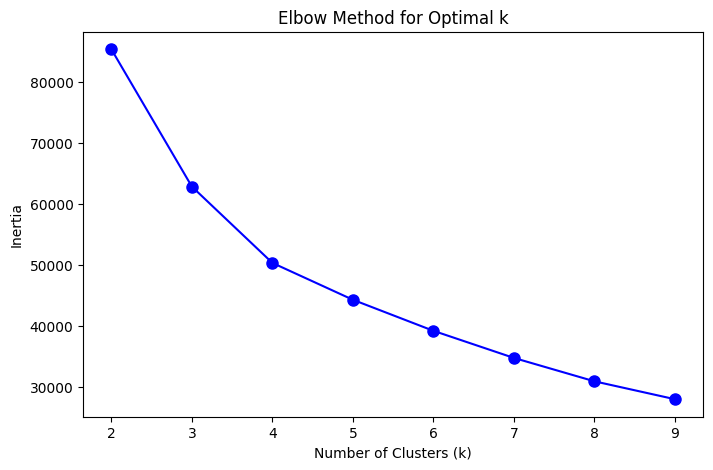

Inertias: [85400.68806001492, 62846.92483115355, 50315.07736743968, 44261.5546923832, 39163.78961312014, 34710.61315345671, 30871.923786048028, 27932.23966471102]


In [3]:
# Clustering
cluster_features = ['avg_temp_c', 'avg_humidity', 'valence', 'energy', 'danceability', 'tempo', 'acousticness']

X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to find optimal k
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.savefig('../results/figures/elbow_plot.png', dpi=150)
plt.show()
print("Inertias:", inertias)

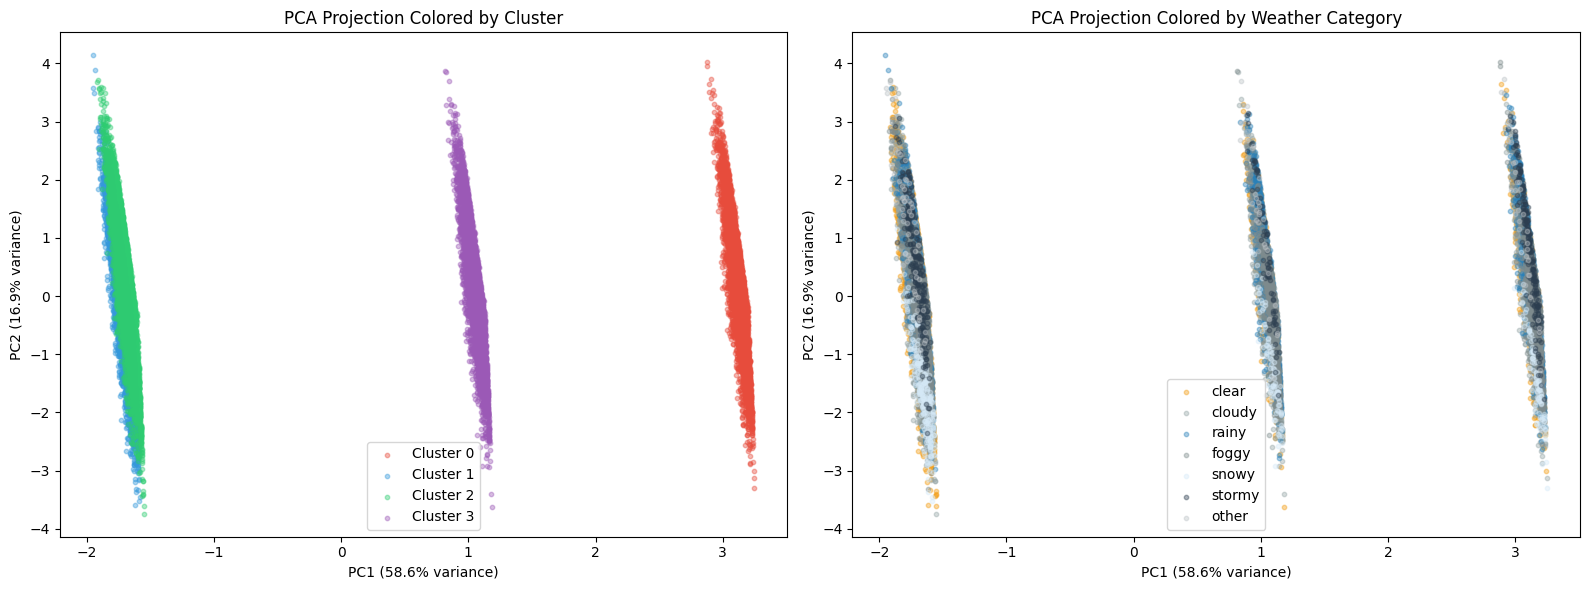

Explained variance: [0.586 0.169]


In [4]:
# Fit KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA colored by cluster
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for cluster in range(4):
    mask = df['cluster'] == cluster
    axes[0].scatter(df[mask]['pca1'], df[mask]['pca2'],
                   c=colors[cluster], label=f'Cluster {cluster}', alpha=0.4, s=10)
axes[0].set_title('PCA Projection Colored by Cluster')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# Plot 2: PCA colored by weather category
weather_colors = {'clear': '#f39c12', 'cloudy': '#95a5a6', 'rainy': '#2980b9',
                  'foggy': '#7f8c8d', 'snowy': '#d6eaf8', 'stormy': '#2c3e50', 'other': '#bdc3c7'}
for cat, color in weather_colors.items():
    mask = df['weather_category'] == cat
    axes[1].scatter(df[mask]['pca1'], df[mask]['pca2'],
                   c=color, label=cat, alpha=0.4, s=10)
axes[1].set_title('PCA Projection Colored by Weather Category')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/pca_clusters.png', dpi=150)
plt.show()

print("Explained variance:", pca.explained_variance_ratio_.round(3))